### Nomenclature 
NN      Neural Network  
PINN       Physics-Informed Neural Network

# Tasks

### Implementation 
1. Import and prepare data
    1. Generate with existing data generator
    2. Visualize
    3. Prepare data for NN training  
    Implement all steps except of step 3
<br><br>

2. Set up Neural Network
    1. Implement NN architecture
    2. Implement Forward Function 
<br><br>
  
3. Write Training
    1. Define and Implement the Data Loss Function
    2. Implement the execution Function
<br><br>

___
### Execution 

4. Verification: Execute Training and Visualize 
    1. Execute the training for the following set of (hyper)parameters.  
    Plot the loss evolution during training and the final prediction of the model (after training).
    Compare the final predictions to the true solution of the trajectory. 
        
        - Use default parameters for the data generation
        - Use 20 points (linearly spaced in time) from the generated data for the train_ds.  
            Use the remaining points for the test_ds
        - Use a neural network with one hidden layer with each having 64 neurons. 
        - learning rate $\eta = 0.01$
        - training epochs $n_\text{epochs} = 300$
<br><br>

5. Hyperameter   
    We could now change all hyperparameters of the model (learning rate, model depth, model width, ...) and identify the best possible configuration for the given task. 
    Even though this is not the goal of this lab course, it is nice to get a rough impression of the effect of a hyperparameter. 
    Therefore, we now tune the learning rate:  
    1. Implement a loop over the following list of learning rates. 
    In each loop we train the neural network using the configuration from task 4 (except of the learning rate). 
    Save all the loss evolutions and the final model predictions.

        Learning rates = [1, 1e-1, 1e-2, 1e-3, 1e-4]

    2. Compare the loss evolutions and the final predictions in two plots.  
    Additionally, plot the true solution of the trajectory to compare the final predictions. 
    
    3. Which learning rate yields the best results?  
    Explain why. 

___
### Implementation 

6. Implement the PINN
    1. Implement the function `compute_physics_informed_loss`
    2. Include the Physics Loss in `compute_total_loss`
    3. Generate Collocation Points that are used to train the physics loss  

            Todo: Implement pipeline for collocation points and link to this task 
                Make default 100
            Todo: Enable the user to activate and deactivate the physics loss from outside. 

___
### Execution 

7. Compare PINN to regular NN.  
    Goal of this task is to identify the difference in performance between a regular NN and a PINN. 
    For that, we change the number of training samples we use to train the data loss. 
    We will use the following three training data sets:  
    
    - 20 equally spaced points over the entire data set.
    - 10 equally space points over the first half of the data. 
    - 2 points using the first and last point of the data set. 

    1. For each of these data sets, execute one training of a PINN (with phsics loss) and one training of regular NN (without physics loss) using the parameter configuration from task 4 (except the training data points). 
    Moreover, use the default value of 100 collocation points for the physics loss. 
    Store the loss evolution and the final model performance of each run. 
    Execute this study by looping over all configurations, which means the study should be executed in one run. 
    
            Todo: Get help with setting up the task

    2. Create 3 plots, one for each set of training data, in which you compare the loss evolution and the final model prediction of the PINN to the regular NN. 


8. Vary Collocation points.  
    1. Now we want to identify the effect of the collocation points when training a PINN.  
    For that we simply vary the number of collocation points using the following setup:

    - 5 linearly spaced over time
    - 20 linearly spaced over time
    - 50 linearly spaced over time
    - 100 linearly spaced over time

    2. Plot and compare the loss evolution and final prediction of all four configurations. 

    3. What can you see, and how can you explain the behavior?

In [1]:

# data_dict = {"data_1": train_ds, "data_2": train, "data_3": train}
# loop_list = [("data_1", True),  ("data_1", False), ("data_2", True), ("data_2", False), ("data_3", True), ("data_3", False)]

# for data_name, activate_physics in loop_list:
#     data = data_dict[data_name]
    

In [ ]:
# import numpy as np

# a = [True, False]
# b = ["a", "b", "c", "d", "e"]

# x, y = np.meshgrid(a, b)
# list(zip(x.ravel(), y.ravel()))


# Physics background

This PINN aims to learn and predict the trajectory of a projectile slowed down by a drag force.

The magnitude of the force depends on the following parameters:
1. $\rho$ the Air density $(\text{kg}/\text{m}^3)$, 
2. $C_d$ the drag coefficient, 
3. $A$ the Cross-sectional area $(\text{m}^2)$

All these parameters can be summarized to one coefficient:
- $\mu = 0.5 * \rho * C_d * A$

Moreover, the drag force depends on the square of the projectile's speed:
- $F = \mu * v * |v|$ 
where $F$ can be split up in $x$-and $y$-components:
- $F_x = \mu * \frac{dx}{dt} * |v|$ and 
- $F_y = \mu * \frac{dy}{dt} * |v|$

The resulting differential equations describe the path of the projectile:
- $\frac{d^2x}{dt^2} = F_x/m$
- $\frac{d^2y}{dt^2} = F_y/m - g$ 

Where $m$ is the Mass of the projectile $(\text{kg})$ and $g$ the earths gravitational acceleration. 

# Library import

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from physics_data_generator import ProjectileDataGenerator, PhysicalSystem
from Animator import AnimationGenerator

# Data generation

In [3]:
# Use existing code to generate training data
physical_system = PhysicalSystem() #PhysicalSystem(drag_coeff=0.0, v_0=torch.tensor([5, 5]))
data_generator = ProjectileDataGenerator(physical_system)

# Generate training data
data_generator.integrate()

# Get training data
time = data_generator.time
position = data_generator.position
velocity = data_generator.velocity
acceleration = data_generator.acceleration

# Get the physical system parameters
g = physical_system.g
Cd = physical_system.drag_coeff
A = physical_system.cross_area
m = physical_system.mass
mu = physical_system.coeff

Text(0, 0.5, 'Vertical Distance (m)')

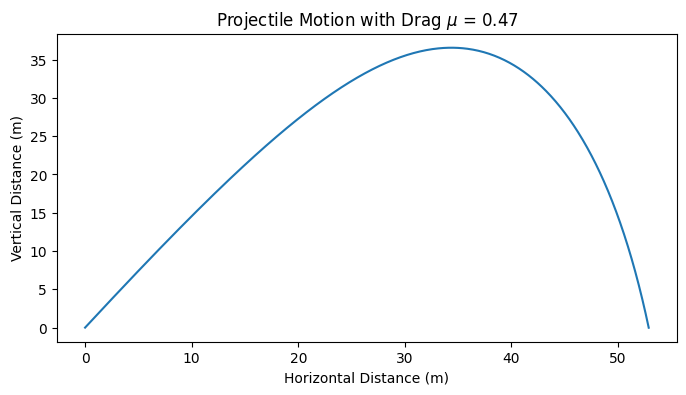

In [4]:
# Todo: Create a plot of the simulated data
# Plot the trajectory of the projectile

plt.figure(figsize=(8, 4))
plt.plot(position[:, 0], position[:, 1])
plt.title(rf"Projectile Motion with Drag $\mu$ = {physical_system.drag_coeff:.2f}")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")

# Data preparation

In [5]:
def create_training_data(
        time_vals, 
        position_vals, 
        num_t_train = 10, 
        sigma_noise = 0.0, 
        max_t_train = 2,
        min_t_train = 0,
        activate_physics = False,
    ):
    """
    Create training data for training procedure.

    This function generates training data using a subset
    of time values ('time_vals' tensor) and corresponding 
    x- and y-components ('position_vals' tensor).
    It can add optional noise to the state values. 
    Therefore the following steps need to be done:
    

    1. Select evenly spaced values from the 'time_vals' and 'position_vals' arrays:
        - Create a list containing indices between 0 and max_t_train*100 to select data points.
        - Ensure that the data type of this list is integer.

    2. Define 't_train', 'x_train', and 'y_train' tensors by selecting index values from 
       'time_vals' and 'position_vals' using '.clone.detach':
        - Format the tensor size as 'torch.Size([num_t_train, 1])'.

    3. Introduce possible noise to the data:
        - Generate a noise tensor with appropriate dimensions using the 'torch.rand(...)' command.
        - Add 'sigma_noise * noise' to the 'x_train' and 'y_train' tensors.
        
    4. Define 't_test' 'x_test' and 'y_test' tensors by picking 
       the right data from the 'position_vals' tensor
        - Format the tensor size as 'torch.Size([len(position_vals), 1])'.
    
    5. Create datasets train_ds and test_ds by using dictionaries 
       containing "inputs", "targets_x" and "targets_y" entries
        
    4. Return the created datasets
    
    Parameters
    ----------
    time_vals : torch.Tensor
        A tensor containing time values.
    position_vals : torch.Tensor
        A tensor containing x- and y-components of the displacementvector.
    num_t_train : int, optional
        The number of data points to select from the provided time. Default is 10.
    sigma_noise : float, optional
        A scaling factor to add noise to the state values. Default is 0 (no noise).
        
    Returns
    -------
    Dict
        a dictionary containing "inputs", "targets_x" and 
          "targets_y" entries for training data.
    Dict
        a dictionary containing "inputs", "targets_x" and 
          "targets_y" entries for testing data.
      
    """
    
    # Step 1: Create a list of indices that correspond to the selected time values.
    idx = torch.linspace(min_t_train*100, max_t_train*100, num_t_train, dtype=torch.int)
    
    # Step 2: Get t_train, x_train and y_train by selecting values from the provided data.
    t_train = time_vals[idx].clone().detach().to(torch.float32).unsqueeze(1)
    x_train = position_vals[idx, 0].clone().detach().unsqueeze(1)
    y_train = position_vals[idx, 1].clone().detach().unsqueeze(1)
    
    # Step 3: Generate and noise times sigma_noise to x_train and y_train
    noise_x = torch.randn(num_t_train).unsqueeze(1)
    noise_y = torch.randn(num_t_train).unsqueeze(1)
    x_train += sigma_noise * noise_x
    y_train += sigma_noise * noise_y
    
    # Step 4: Get t_test, x_test, y_test from the provided data
    t_test = time_vals.unsqueeze(1)
    x_test = position_vals[:, 0].unsqueeze(1)
    y_test = position_vals[:, 1].unsqueeze(1)
    
    # Step 5: Create datasets train_ds and test_ds by using dictionaries 
    train_ds = {"inputs": t_train, "targets_x": x_train,"targets_y": y_train}
    test_ds = {"inputs": t_test, "targets_x": x_test, "targets_y": y_test}

    # Step 6: return datasets
    return train_ds, test_ds


# Create PINN model

In [6]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network (PINN) Class
    
    This class as a subclass of torch.nn.Module defines the architecture of the PINN model. 
    It is designed to use differential equations while incorporating physics-based constraints.
    The process consists of the following steps:
    
    1. Initialize the PINN model as a subclass of nn.Module.
    
    2. Build a Constructor to Configure the models's architecture. 
       Utilize the nn.Linear class from the PyTorch library for defining layers and connections.
       
    3. Define the forward pass mechanism for the model, where input data flows
       through the layers to produce predicted outputs.
       
    """
    def __init__(self):
        """
        Constructor for the PINN class.
        
        Initializes the layers of the neural network:
        - Input layer fc1 taking a tensor with time data.
        - One hidden fully connected layer fc2 with 64 neurons.
        - Output layer fc_x for predicting the x-coordinate.
        - Output layer fc_y for predicting the y-coordinate.
        
        Parameters
        ----------
        None
            
        Attributes
        ----------
        fc1 : nn.Linear
            First fully connected layer.
        fc2 : nn.Linear
            Second fully connected layer.
        fc_x : nn.Linear
            Output layer for x-coordinate prediction.
        fc_y : nn.Linear
            Output layer for y-coordinate prediction.
        
        Returns
        -------
        None
        
        """
        super(PINN, self).__init__()
        
        # Step 2: Configure model architecture as described earlier
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc_x = nn.Linear(64, 1)
        self.fc_y = nn.Linear(64, 1)
    
    def forward(self, t):
        """
        Perform a forward pass through the PINN model.
        
        This method defines the forward pass mechanism of the PINN model, where
        the input data t is processed through the layers to produce predicted
        outputs for both x-coordinate (x_output) and y-coordinate (y_output).
        The following steps are necessary:
        
        1. Apply the First Fully Connected Layer with GELU Activation:
           - Pass the input tensor t through the fc1 linear layer.
           - Convert the input to the dtype you have defined in step 1 data type for compatibility.
           - Apply the GELU activation function 'torch.nn.functional.gelu(...)' to the output.
        
        2. Apply the Second Fully Connected Layer with GELU Activation:
           - Pass the output of the previous step (t) through the fc2 linear layer.
           - Convert the input to the dtype as in the previous step.
           - Apply the GELU activation function to the output.
        
        3. Produce Predicted x and y Coordinates Using Output Layers:
           - Compute the predicted x-coordinate by passing the transformed tensor t through the fc_x layer.
           - Compute the predicted y-coordinate by passing the same transformed tensor t through the fc_y layer.
        
        Parameters
        ----------
        t : torch.Tensor
            Input data tensor.
            
        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Predicted x and y coordinates.
        """

        # Step 1: Apply the first fully connected layer with GELU activation
        t = torch.nn.functional.gelu(self.fc1(t))
        
        # Step 2: Apply the second fully connected layer with GELU activation
        t = torch.nn.functional.gelu(self.fc2(t))
        
        # Step 3: Produce predicted x and y coordinates using output layers
        x_output = self.fc_x(t)  # Predicted x-coordinate
        y_output = self.fc_y(t)  # Predicted y-coordinate
        
        return x_output, y_output


# Physicis informed loss

In [7]:
def compute_physics_informed_loss(model, t_tensor):
    """
    Define the physics-informed loss for the PINN model.
    
    This function calculates the loss used to incorporate the underlying physics
    principles into the PINN. The following steps are involved:
    
    1. Enable gradient computation for the collocation points tensor, t_tensor.
    
    2. Predict x and y values by calling the neural network model.
    
    3. Compute the first gradients dx_dt and dy_dt, and second gradients d2x_dt2
       and d2y_dt2, using the torch.autograd.grad command

    4. Calculate the speed v using the Euclidean norm of the vector [dx_dt, dy_dt].
       Define the x and y component of the drag force as in the Data generation Block above.
       
    
    5. Define the differential equation residuals for both x and y components.
       (see [residuals](https://www.displayr.com/learn-what-are-residuals/))
       
    6. Calculate the mean squared residuals for both x and y using torch.mean().

    7. Return the combined physics-informed loss as the sum of loss_x and loss_y.
    
    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    t_tensor : torch.Tensor
        Train points tensor with requires_grad=True.
        
    Returns
    -------
    torch.Tensor
        The combined (x and y) physics-informed loss.
    """
    # Step 1: Enable gradient computation for t_tensor
    t_tensor.requires_grad = True
    
    # Step 2: Predict x and y values using the neural network model
    x_pred, y_pred = model(t_tensor)
    
    # Step 3: Compute first and second gradients
    dx_dt = torch.autograd.grad(torch.sum(x_pred), t_tensor, create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(torch.sum(dx_dt), t_tensor, create_graph=True)[0]
    
    dy_dt = torch.autograd.grad(torch.sum(y_pred), t_tensor, create_graph=True)[0]
    d2y_dt2 = torch.autograd.grad(torch.sum(dy_dt), t_tensor, create_graph=True)[0]
    
    # Step 4: Calculate the speed v using the Euclidean norm and define x and y component of the drag force.
    v = torch.sqrt(dx_dt ** 2 + dy_dt ** 2)
    Fx = -mu * v * dx_dt
    Fy = -mu * v * dy_dt
    
    # Step 5: Define differential equation residuals
    residual_x = d2x_dt2 - Fx / m
    residual_y = d2y_dt2 - ((Fy / m) - g)
    
    # Step 6: Calculate mean squared residuals
    loss_x = torch.mean(residual_x ** 2)
    loss_y = torch.mean(residual_y ** 2)
    
    # Step 7: Return the combined (x and y) physics-informed loss
    return loss_x + loss_y


# Data loss

In [8]:
def compute_data_loss(model, dataset: dict):
    """
    Define the data loss for the PINN model.
    
    This function calculates the loss based on the discrepancy between the predicted
    and actual data points, typically used for data-driven training of the PINN. The
    following steps are involved:
    
    1. Compute the predicted x and y values by calling the neural network model.
    
    2. Calculate the mean squared error loss for both the x and y components using the nn.MSELoss() class.
       (see [MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html))
       
    3. Return the combined data loss as the sum of mse_x and mse_y.
    
    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    t_train : torch.Tensor
        A tensor containing selected time values for training.
    x_train : torch.Tensor
        A tensor containing selected x-coordinate state values for training.
    y_train : torch.Tensor
        A tensor containing selected y-coordinate state values for training.
        
    Returns
    -------
    torch.Tensor
        The combined data loss based on predicted vs. actual data.
    """
    # Step 1: Compute predicted x and y values using the neural network model
    x_pred, y_pred = model(dataset["inputs"])
    
    # Step 2: Calculate mean squared error loss
    mse_loss = nn.MSELoss()
    mse_x = mse_loss(x_pred, dataset["targets_x"])
    mse_y = mse_loss(y_pred, dataset["targets_y"])
    
    # residual_x = x_pred - dataset["targets_x"]
    # residual_y = y_pred - dataset["targets_y"]
    # loss_x = torch.mean(residual_x ** 2)
    # loss_y = torch.mean(residual_y ** 2)
    
    # Step 3: Return the combined (x and y) data loss
    return mse_x + mse_y

# Total Loss

In [9]:
def compute_total_loss(model, dataset: dict, t_col, activate_physics=False):
    """
    Define the total loss for the physics-informed neural network.
    
    This function computes the total loss for the PINN model by combining three
    different components: data loss, and physics-informed loss.
    The following steps are involved:
    
    1. Compute the physics-informed loss by calling 
       the compute_physics_informed_loss() function.
    
    2. Determine the data loss using the compute_data_loss() function.
    
    3. Return the combined total loss as the sum of data_loss and phys_loss.
    
    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "inputs", "targets_x" and "targets_y" entries.
    t_col : torch.Tensor
        A tensor containing collocation points for the physics-informed loss.
        
    Returns
    -------
    torch.Tensor
        The combined total loss considering data and physics constraints.
    """
        
    # Step 1: Compute physics-informed loss
    phys_loss = compute_physics_informed_loss(model, t_col)
    
    # Step 2: Determine data loss
    data_loss = compute_data_loss(model, dataset)
    # Step 3: Return combined total loss
    if activate_physics == False:
        total_loss = data_loss
    else:
        total_loss = data_loss + phys_loss
    return total_loss


# Executive function

In [24]:
def execute(
        model,
        test_ds,
        train_ds,
        lr = 0.005, 
        num_epochs = 1000,
        weight_decay = 1e-5,
        activate_physics = False,
        num_t_col = None,
        min_t_col = 0,
        max_t_col = 5,
    ):
    """
    Execute the training procedure for a physics-informed neural network model.

    This function trains the model using specified hyperparameters and returns relevant data.
    The process involves the following steps:
    
    Step 1:. The optimizer is used to update the model's parameters during training. Therefore:
            - Initialize the optimizer, Adam with the model parameters.
            - Configure it with a specified learning rate (lr) and weight decay (weight_decay).
        
    Step 2: In order to store the values of the loss function during the training process:
            - Initialize a list called 'loss_evolution'. 

    Step 3: Set up a training loop that will run for a specified number of epochs ('num_epochs'). 
            An epoch is one complete pass through the entire training dataset.

    Step 4: - Inside the training loop, 
              the optimizer's gradient is reset to zero using 'optimizer.zero_grad()' to 
              prepare for a new gradient calculation. 
        
    Step 5: - Calculate the total loss using the 'compute_total_loss' function. 
            - Additionally, include a term for L2 regularization, by using the torch.norm() command 
              and make sure it is the second order. 
            - Then sum over all parameters of the model.

    Step 6: - Then calculate the gradients of the model's parameters with respect to the total loss 
              using 'loss.backward()'. 
            - These gradients will be used by the optimizer to update the model's parameters.

    Step 7: - Now append the current loss value (including regularization) 
              to the 'loss_evolution' list for later analysis. 
            - Additionally, every 10 epochs, the code prints the current epoch number 
              and the value of the loss.

    Step 8: Once the training loop is completed, return 'loss_evolution' and 'num_epochs'.

    Parameters
    ----------
    train_ds : dict
        A dictionary containing training data, including inputs and targets.
    test_ds : dict
        A dictionary containing test data, including inputs and targets.
    lr : float, optional
        Learning rate for the optimizer. Default is 0.01.
    num_epochs : int, optional
        Number of training epochs. Default is 1000.
    weight_decay : float, optional
        Weight decay (L2 regularization) strength for the optimizer. Default is 1e-5.
    num_t_col : int, optional
        The number of colocation points to use for the physics-informed loss. Default is None.
    min_t_col : int, optional
        The starting time value to use for the colocation points. Default is 0.
    max_t_col : int, optional
        The maximum time value to use for the colocation points. Default is 5.

    Returns
    -------
    list
        A list containing train loss values during training.
    list
        A list containing test loss values during training
    int
        The number of training epochs.
    
    """    
    
    # Step 1: Initialize optimizer 
    optimizer = optim.Adam(model.parameters(), lr=lr,)  # Include weight_decay in the optimizer
    
    # implement query of taking different collocation points for the physics loss or the training data
    if num_t_col == None:
        t_col = train_ds["inputs"]
    else:
        t_col = torch.linspace(min_t_col, max_t_col, num_t_col).unsqueeze(1)
    # Step 2: Initialize the loss evolution list.
    train_loss_evolution = []
    test_loss_evolution = []
    predictions_list = []
    
    # Step 3: Set up the training loop
    for epoch in range(num_epochs):
        
        # Step 4: Reset the optimizers gradient
        optimizer.zero_grad()
        
        # Step 5: Compute the total loss for the training and the test data.
        train_loss = compute_total_loss(model, train_ds, t_col, activate_physics=activate_physics)
        test_loss = compute_total_loss(model, test_ds, t_col)
        
        # Calculate the L2 regularization term and add to the loss.
        l2_regularization = 0.0
        for param in model.parameters():
            l2_regularization += torch.norm(param, p=2) #** 2  # L2 norm of parameters
            
        train_loss += weight_decay * l2_regularization
        
        # Step 6 calculate the gradients using backpropagation
        train_loss.backward()
        optimizer.step()

        

        # Step 7: Store the current loss value in the loss history and print every 100th epoch the Loss.
        train_loss_evolution.append(float(train_loss))
        test_loss_evolution.append(float(test_loss))
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], train_loss: {train_loss.item()}')
            print(f'Epoch [{epoch+1}/{num_epochs}], test_loss: {test_loss.item()}')
            
        
        model.eval()  # Set the model to evaluation mode
        with torch.no_grad():
            predictions = model(test_ds["inputs"])  # Make predictions
        predictions_list.append(predictions)
        model.train()  # Set the model back to training mode
            
    
    # Step 8: return loss_evolution, num_epochs
    return train_loss_evolution, test_loss_evolution, predictions_list

# Execute

In [31]:
# Initialize the model by calling the PINN() class created earlier.
model = PINN()

train_ds, test_ds = create_training_data(
    time_vals=time, 
    position_vals=position, 
    num_t_train=3,
    min_t_train=0.0,
    max_t_train=time[-1],
    sigma_noise=0, 
)
print(train_ds)
train_loss_evolution, test_loss_evolution, predictions_list = execute(
    model,
    test_ds,
    train_ds,
    num_epochs=300,
    num_t_col=50,
    min_t_col=0,
    max_t_col=time[-1],
    weight_decay=1e-6,
    activate_physics=False
)
print(predictions_list[-1])

{'inputs': tensor([[0.0000],
        [2.7100],
        [5.4200]]), 'targets_x': tensor([[ 0.0000],
        [39.3413],
        [52.8758]]), 'targets_y': tensor([[ 0.0000e+00],
        [ 3.4941e+01],
        [-1.5291e-02]])}
Epoch [20/300], train_loss: 751.5684814453125
Epoch [20/300], test_loss: 905.880859375
Epoch [40/300], train_loss: 296.1466979980469
Epoch [40/300], test_loss: 495.60693359375
Epoch [60/300], train_loss: 147.24777221679688
Epoch [60/300], test_loss: 237.0670928955078
Epoch [80/300], train_loss: 26.78411293029785
Epoch [80/300], test_loss: 61.154624938964844
Epoch [100/300], train_loss: 0.894707441329956
Epoch [100/300], test_loss: 14.547307014465332
Epoch [120/300], train_loss: 0.4032822847366333
Epoch [120/300], test_loss: 20.58499526977539
Epoch [140/300], train_loss: 0.011029070243239403
Epoch [140/300], test_loss: 17.416095733642578
Epoch [160/300], train_loss: 0.003894520690664649
Epoch [160/300], test_loss: 17.812055587768555
Epoch [180/300], train_loss: 0.0005

# Network prediction


In [32]:
# Generate Network prediction of the trained model
t = test_ds["inputs"]
x_pred, y_pred = model(t)

# Plot

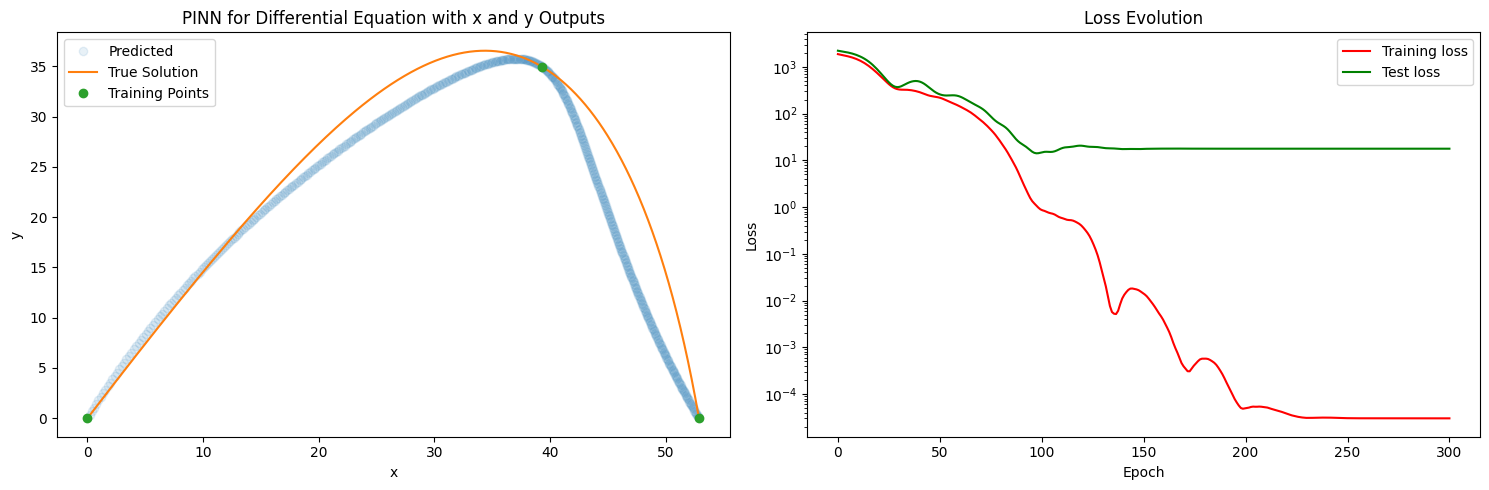

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with subplots
fig, axs = plt.subplots(1, 2, figsize=(15,5))  # 1 row, 2 columns of subplots

# Plot data on the first subplot
axs[0].plot(x_pred.detach().numpy(), y_pred.detach().numpy(), 'o', alpha=0.1, label='Predicted')
axs[0].plot(test_ds["targets_x"], test_ds["targets_y"], label='True Solution')
axs[0].plot(train_ds["targets_x"].detach().numpy(), train_ds["targets_y"].detach().numpy(), 'o', label='Training Points')
axs[0].legend()
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('PINN for Differential Equation with x and y Outputs')
# axs[0].set_ylim(-20, 60)
# axs[0].set_xlim(-20, 60)

# Plot loss evolution on the second subplot

axs[1].plot(np.linspace(0, len(train_loss_evolution), len(train_loss_evolution)), train_loss_evolution, c='r', label='Training loss')
axs[1].plot(np.linspace(0, len(test_loss_evolution), len(test_loss_evolution)), test_loss_evolution, c='g', label='Test loss')
axs[1].legend()
axs[1].set_title('Loss Evolution')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_yscale('log')  # Set y-axis to logarithmic scale
# Adjust layout for subplots
plt.tight_layout()

# Show the plot
plt.show()


# Animation

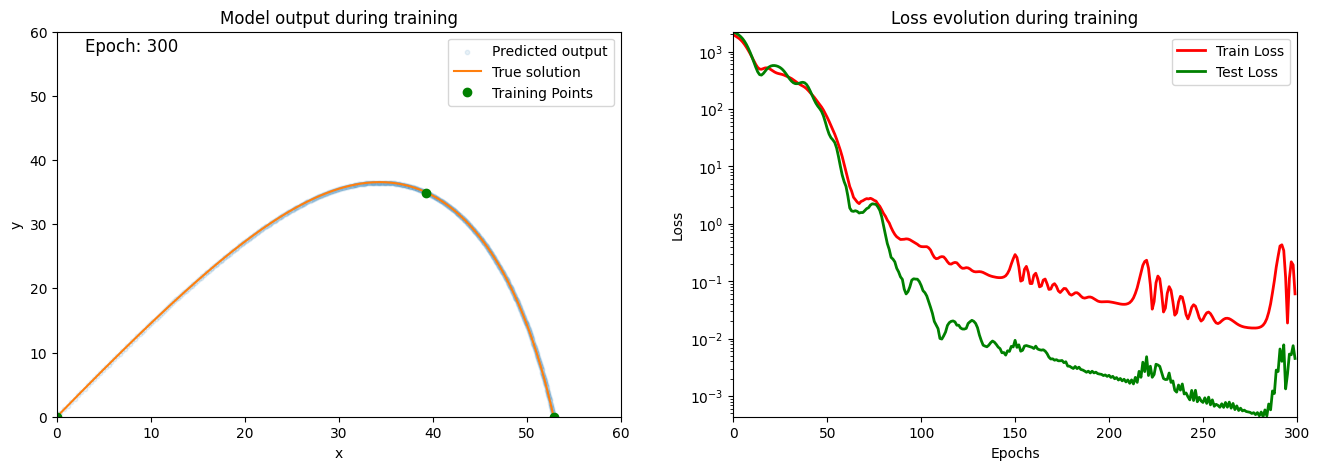

In [185]:
# Example usage:
animator = AnimationGenerator(train_loss_evolution, 
                              test_loss_evolution, 
                              predictions_list, 
                              train_ds, 
                              test_ds)
animator.create_animation('data_loss.mp4', frames=300, fps=30)

# Evaluation Task

In [44]:
# Initialize an empty dictionary to store data
data_dict = {}

# Create a Looplist, with all important information for the data Generatrion (num_t_train, min_t_train, max_t_train)
Looplist = [(20, 0, time[-1]), (10, 0, time[-1]/2), (2, 0, time[-1])]

# Initialize test_ds before the loop so it can be used after the loop.
test_ds = None

for i, (num_t_train, min_t_train, max_t_train) in enumerate(Looplist):

    train_ds, test_ds = create_training_data(
        time_vals=time,
        position_vals=position,
        num_t_train=num_t_train,
        min_t_train=min_t_train,
        max_t_train=max_t_train,
        sigma_noise=0
    )
    key = f"data_{i}"
    data_dict[key] = train_ds
print(data_dict)
for data_key, data_value in data_dict.items():
    # Initialize the model by calling the PINN() class created earlier.
    model = PINN()
    
    # Now, you can use sub_dict as a dictionary and pass it as input to your function
    # Execute the training for the given data_set
    train_loss_evolution, test_loss_evolution, predictions_list = execute(
        test_ds,
        train_ds = data_value,
        num_epochs=300,
        lr=0.005, 
        num_t_col=50,
        min_t_col=0,
        max_t_col=time[-1],
        weight_decay=1e-6)
    
    # Generate the model prediction
    x_pred, y_pred = model(test_ds["inputs"])
    
    # Create a new sub_dict with all data that contains relevant for the plots
    data_value = {
        "train_loss_evolution": train_loss_evolution,
        "test_loss_evolution": test_loss_evolution,
        "x_pred": x_pred,
        "y_pred": y_pred
    }
    # Add the sub-dictionary to data_dict keys (data_1,...)
    data_dict[data_key] = data_value
    # check if the data_dict contains the right subkeys ("train_loss_evolution", "test_loss_evolution", "x_pred", "y_pred").
    print(data_dict[data_key].keys())
# check if the data_dict contains the right keys ("data_0", "data_1", "data_2").
print(data_dict.keys())


{'data_0': {'inputs': tensor([[0.0000],
        [0.2800],
        [0.5700],
        [0.8500],
        [1.1400],
        [1.4200],
        [1.7100],
        [1.9900],
        [2.2800],
        [2.5600],
        [2.8500],
        [3.1300],
        [3.4200],
        [3.7000],
        [3.9900],
        [4.2700],
        [4.5600],
        [4.8400],
        [5.1300],
        [5.4200]]), 'targets_x': tensor([[ 0.0000],
        [ 8.8486],
        [15.1550],
        [19.8657],
        [23.9065],
        [27.2825],
        [30.4042],
        [33.1530],
        [35.7846],
        [38.1456],
        [40.4141],
        [42.4329],
        [44.3427],
        [46.0108],
        [47.5595],
        [48.8888],
        [50.1043],
        [51.1344],
        [52.0665],
        [52.8758]]), 'targets_y': tensor([[ 0.0000e+00],
        [ 1.2940e+01],
        [ 2.1468e+01],
        [ 2.7138e+01],
        [ 3.1257e+01],
        [ 3.3964e+01],
        [ 3.5698e+01],
        [ 3.6474e+01],
        [ 3.6437e+01],
 